# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is a subset of machine learning and artificial intelligence
neural networks are inspired by the human brain structure
recurrent neural networks process data in sequential order
long short term memory networks solve the vanishing gradient problem
gated recurrent units are simpler and faster than lstm networks
attention mechanism helps models focus on relevant parts of input
transformers use self attention to process entire sequences at once
natural language processing enables computers to understand human language
text generation models learn patterns from large amounts of text data
word embeddings represent words as dense numerical vectors in space
training a neural network involves minimizing the loss function gradually
backpropagation through time is used to train recurrent neural networks
deep learning models require large datasets and significant computing power
transfer learning allows models to reuse knowledge from previous training
artificial intelligence is transforming industries like healthcare and finance
machine learning algorithms improve automatically through experience and data
convolutional neural networks are powerful for image recognition tasks
generative models can create new text images and audio from learned patterns
the softmax function converts raw scores into probability distributions
gradient descent is the optimization algorithm used in most neural networks
'''
print(corpus)


deep learning is a subset of machine learning and artificial intelligence
neural networks are inspired by the human brain structure
recurrent neural networks process data in sequential order
long short term memory networks solve the vanishing gradient problem
gated recurrent units are simpler and faster than lstm networks
attention mechanism helps models focus on relevant parts of input
transformers use self attention to process entire sequences at once
natural language processing enables computers to understand human language
text generation models learn patterns from large amounts of text data
word embeddings represent words as dense numerical vectors in space
training a neural network involves minimizing the loss function gradually
backpropagation through time is used to train recurrent neural networks
deep learning models require large datasets and significant computing power
transfer learning allows models to reuse knowledge from previous training
artificial intelligence is trans

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 134
X shape: (177, 11)
y shape: (177,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [10]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [11]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [12]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


In [15]:
stacked_lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dense(total_words, activation='softmax')
])
stacked_lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
stacked_history = stacked_lstm_model.fit(X, y, epochs=200, verbose=0)
print("Stacked LSTM training completed")

Stacked LSTM training completed


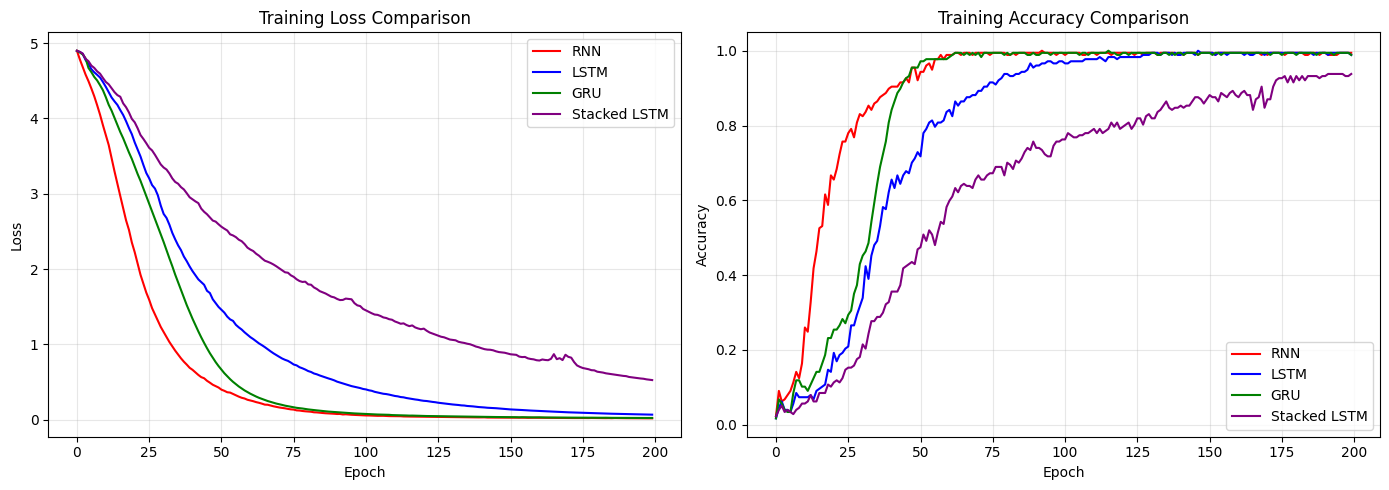

In [16]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['loss'], label='RNN', color='red')
plt.plot(lstm_history.history['loss'], label='LSTM', color='blue')
plt.plot(gru_history.history['loss'], label='GRU', color='green')
plt.plot(stacked_history.history['loss'], label='Stacked LSTM', color='purple')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['accuracy'], label='RNN', color='red')
plt.plot(lstm_history.history['accuracy'], label='LSTM', color='blue')
plt.plot(gru_history.history['accuracy'], label='GRU', color='green')
plt.plot(stacked_history.history['accuracy'], label='Stacked LSTM', color='purple')
plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
print(f"{'Model':<15} {'Final Loss':<15} {'Final Accuracy'}")
print("-"*45)
print(f"{'RNN':<15} {rnn_history.history['loss'][-1]:<15.4f} {rnn_history.history['accuracy'][-1]:.4f}")
print(f"{'LSTM':<15} {lstm_history.history['loss'][-1]:<15.4f} {lstm_history.history['accuracy'][-1]:.4f}")
print(f"{'GRU':<15} {gru_history.history['loss'][-1]:<15.4f} {gru_history.history['accuracy'][-1]:.4f}")
print(f"{'Stacked LSTM':<15} {stacked_history.history['loss'][-1]:<15.4f} {stacked_history.history['accuracy'][-1]:.4f}")

Model           Final Loss      Final Accuracy
---------------------------------------------
RNN             0.0160          0.9944
LSTM            0.0651          0.9887
GRU             0.0210          0.9887
Stacked LSTM    0.5244          0.9379


In [18]:
seeds = ["deep learning", "neural networks", "attention mechanism", "artificial intelligence"]

for seed in seeds:
    print(f"\nSeed: '{seed}'")
    print(f"  RNN         : {generate_text(rnn_model, seed, 10)}")
    print(f"  LSTM        : {generate_text(lstm_model, seed, 10)}")
    print(f"  GRU         : {generate_text(gru_model, seed, 10)}")
    print(f"  Stacked LSTM: {generate_text(stacked_lstm_model, seed, 10)}")


Seed: 'deep learning'
  RNN         : deep learning models require large datasets and significant computing power finance process
  LSTM        : deep learning models require large datasets and significant computing power power learned
  GRU         : deep learning models require large datasets and significant computing power power power
  Stacked LSTM: deep learning is a subset of machine learning and artificial intelligence intelligence

Seed: 'neural networks'
  RNN         : neural networks are inspired by the human brain structure image gradient problem
  LSTM        : neural networks are inspired by the human brain structure problem problem space
  GRU         : neural networks are inspired by the human brain structure structure structure structure
  Stacked LSTM: neural networks are inspired by the human brain structure problem problem deep

Seed: 'attention mechanism'
  RNN         : attention mechanism helps models focus on relevant parts of input data in
  LSTM        : atte

## 📉 Compare Training Loss

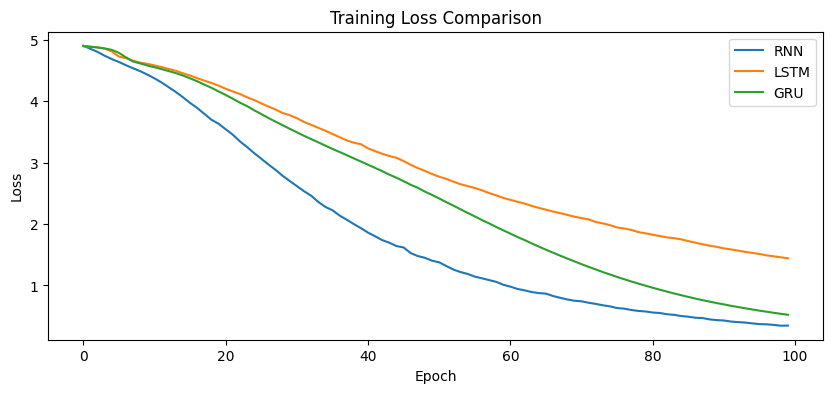

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [13]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [14]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning models require large datasets and significant computing power finance process
LSTM: deep learning models require large datasets and significant computing power power learned
GRU : deep learning models require large datasets and significant computing power power power


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**
# Conclusion

Trained and compared RNN, LSTM, GRU, and Stacked LSTM on a custom corpus.

RNN overfit fastest — lowest loss but just memorized the data.
GRU was the most balanced — fast convergence, decent output.
LSTM was slower but generated more stable text.
Stacked LSTM had highest loss because the corpus was too small for its capacity —
on larger data it would outperform all three.

All models repeated words after exhausting known sequences —
this is an argmax limitation, not a model failure.

Main takeaway — bigger model does not always mean better results.
Dataset size and model capacity need to match.